In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans

In [12]:
df = pd.read_csv('../data/train.csv')


# Check shape, first rows, and basic info
print(df.shape)
print(df.head())
print(df.info())

(1000000, 10)
          id  vendor_id      pickup_datetime  passenger_count  \
0  id2793718          2  2016-06-08 07:36:19                1   
1  id3485529          2  2016-04-03 12:58:11                1   
2  id1816614          2  2016-06-05 02:49:13                5   
3  id1050851          2  2016-05-05 17:18:27                2   
4  id0140657          1  2016-05-12 17:43:38                4   

   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.985611        40.735943         -73.980331         40.760468   
1        -73.978394        40.764351         -73.991623         40.749859   
2        -73.989059        40.744389         -73.973381         40.748692   
3        -73.990326        40.731136         -73.991264         40.748917   
4        -73.789497        40.646675         -73.987137         40.759232   

  store_and_fwd_flag  trip_duration  
0                  N           1040  
1                  N            827  
2                 

       pickup_latitude  pickup_longitude  dropoff_latitude  dropoff_longitude
count   1000000.000000    1000000.000000    1000000.000000     1000000.000000
mean         40.750947        -73.973475         40.751829         -73.973421
std           0.033745          0.065404          0.035782           0.065432
min          34.359695       -121.933342         34.359695        -121.933304
25%          40.737372        -73.991852         40.735928         -73.991341
50%          40.754131        -73.981728         40.754551         -73.979767
75%          40.768379        -73.967346         40.769833         -73.963036
max          51.881084        -61.335529         43.921028         -61.335529


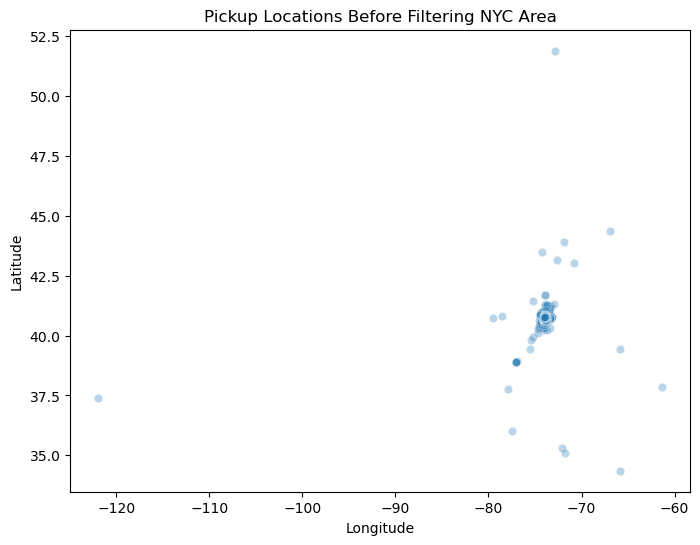

Number of trips completely outside NYC: 3390 out of 1000000
Number of trips after filtering: 996610


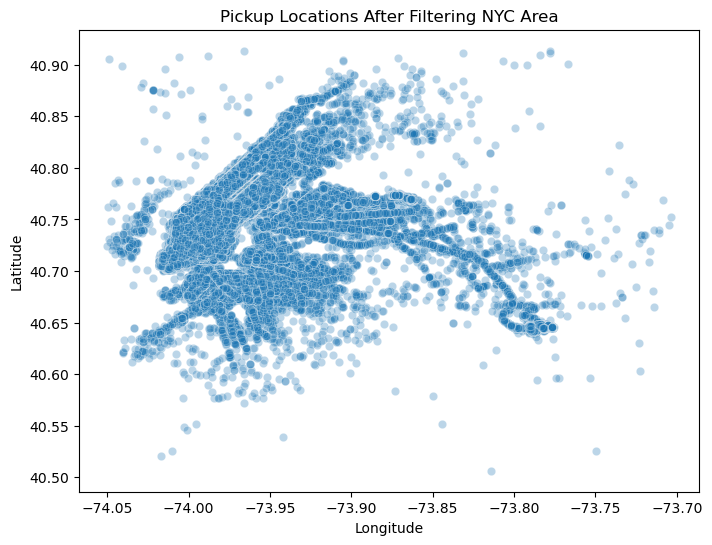

In [13]:
# Descriptive statistics for coordinates
print(df[['pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude']].describe())

# Scatter plot of pickup locations before filtering
plt.figure(figsize=(8, 6))
sns.scatterplot(x='pickup_longitude', y='pickup_latitude', data=df, alpha=0.3)
plt.title("Pickup Locations Before Filtering NYC Area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Define reasonable NYC boundaries
lat_min, lat_max = 40.5, 40.92
lon_min, lon_max = -74.05, -73.7

# Filter trips within NYC boundaries
nyc_mask = (
    (df['pickup_latitude'].between(lat_min, lat_max)) &
    (df['pickup_longitude'].between(lon_min, lon_max)) &
    (df['dropoff_latitude'].between(lat_min, lat_max)) &
    (df['dropoff_longitude'].between(lon_min, lon_max))
)

# Count trips outside NYC boundaries
num_outside = (~nyc_mask).sum()
print(f"Number of trips completely outside NYC: {num_outside} out of {len(df)}")

# Keep only trips within NYC
df = df[nyc_mask].copy()
print(f"Number of trips after filtering: {len(df)}")

# Scatter plot of pickup locations after filtering
plt.figure(figsize=(8, 6))
sns.scatterplot(x='pickup_longitude', y='pickup_latitude', data=df, alpha=0.3)
plt.title("Pickup Locations After Filtering NYC Area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [14]:
!pip install holidays

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 2.3 MB/s eta 0:00:00a 0:00:01


In [15]:
import holidays

us_holidays = holidays.US(years=list(range(2016,2050)), state='NY')  


df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['pickup_date'] = df['pickup_datetime'].dt.date
df['is_holiday'] = df['pickup_datetime'].dt.date.isin(us_holidays).astype(int)  
df['dayofweek'] = df.pickup_datetime.dt.dayofweek
df['month'] = df.pickup_datetime.dt.month
df['hour'] = df.pickup_datetime.dt.hour
df['day'] = df.pickup_datetime.dt.day

In [16]:
df['rush_hours'] = ((df['hour'].between(8,10)) | (df['hour'].between(17,21))).astype(int)
df["night_flag"] = np.where((df["hour"] >= 21) | (df["hour"] < 5), 1, 0)
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

In [17]:
# Identify and Handle Anomalies:
daily_trip_count = df.groupby('pickup_date').size()
z_scores = (daily_trip_count - daily_trip_count.mean()) / daily_trip_count.std()
anomalous_days = z_scores[abs(z_scores) > 2].index

df['is_anomaly'] = df['pickup_date'].apply(lambda x: 1 if x in anomalous_days else 0)

In [18]:

def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance in kilometers
    between two points on the earth (specified in decimal degrees).
    """
    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    
    # haversine formula
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a)) 
    r = 6371  # Radius of earth in kilometers
    return c * r

In [19]:
# Apply to dataset
df['haversine_distance'] = haversine(
    df['pickup_longitude'], df['pickup_latitude'],
    df['dropoff_longitude'], df['dropoff_latitude']
)


In [20]:
df["manhattan_distance"] = (
    np.abs(df["dropoff_longitude"] - df["pickup_longitude"]) +
    np.abs(df["dropoff_latitude"] - df["pickup_latitude"])
)

In [21]:
def bearing(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    return (np.degrees(np.arctan2(x, y)) + 360) % 360


In [22]:
df["bearing"] = bearing(
    df["pickup_longitude"], df["pickup_latitude"],
    df["dropoff_longitude"], df["dropoff_latitude"]
)

In [23]:
# Analyze Traffic Congestion:
df['speed'] = df['haversine_distance'] / (df['trip_duration'] / 3600)
df['mean_speed'] = df.groupby(['dayofweek','hour'])['speed'].transform('mean')
df['std_speed']  = df.groupby(['dayofweek','hour'])['speed'].transform('std')

df['z_score'] = (df['speed'] - df['mean_speed']) / df['std_speed']

df['traffic_congestion'] = (df['z_score'] < -1).astype(int)

df['congestion_rate'] = df.groupby(['dayofweek','hour'])['traffic_congestion'].transform('mean')
df.drop(columns=['traffic_congestion','z_score','std_speed','mean_speed'], inplace=True)

In [24]:
# Airport Proximity Features: 
airports = {
    'JFK': (-73.7781, 40.6413),   # lon, lat
    'LGA': (-73.8740, 40.7769),   # lon, lat
    'EWR': (-74.1745, 40.6895)    # lon, lat
}

threshold_distance = 1  # 1 km

def is_near_airport(lon, lat, airports=airports, threshold=1):
    for airport_coords in airports.values():
        if haversine(lon, lat, *airport_coords) <= threshold:
            return True
    return False


df['is_pickup_at_airport'] = df.apply(lambda row: is_near_airport(row['pickup_longitude'], row['pickup_latitude'], airports, threshold_distance), axis=1).astype(int)
df['is_dropoff_at_airport'] = df.apply(lambda row: is_near_airport(row['dropoff_longitude'], row['dropoff_latitude'], airports, threshold_distance), axis=1).astype(int)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 996610 entries, 0 to 999999
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id                     996610 non-null  object        
 1   vendor_id              996610 non-null  int64         
 2   pickup_datetime        996610 non-null  datetime64[ns]
 3   passenger_count        996610 non-null  int64         
 4   pickup_longitude       996610 non-null  float64       
 5   pickup_latitude        996610 non-null  float64       
 6   dropoff_longitude      996610 non-null  float64       
 7   dropoff_latitude       996610 non-null  float64       
 8   store_and_fwd_flag     996610 non-null  object        
 9   trip_duration          996610 non-null  int64         
 10  pickup_date            996610 non-null  object        
 11  is_holiday             996610 non-null  int64         
 12  dayofweek              996610 non-null  int32    

In [26]:
df = df.drop(columns=["id"])  # Assuming 'id' is not needed for modeling
df = df.drop(columns=["pickup_datetime"])

print("After dropping:", df.shape)


After dropping: (996610, 25)


In [27]:
df["log_trip_duration"] = np.log1p(df["trip_duration"])
print (df.head(10))

   vendor_id  passenger_count  pickup_longitude  pickup_latitude  \
0          2                1        -73.985611        40.735943   
1          2                1        -73.978394        40.764351   
2          2                5        -73.989059        40.744389   
3          2                2        -73.990326        40.731136   
4          1                4        -73.789497        40.646675   
5          2                3        -73.969833        40.768570   
6          2                1        -73.988419        40.760006   
7          1                1        -73.987854        40.749695   
8          2                1        -73.955017        40.764462   
9          1                1        -73.971535        40.794827   

   dropoff_longitude  dropoff_latitude store_and_fwd_flag  trip_duration  \
0         -73.980331         40.760468                  N           1040   
1         -73.991623         40.749859                  N            827   
2         -73.973381   

In [28]:
def sin_cos_encode(values, period):
    return np.sin(2 * np.pi * values / period), np.cos(2 * np.pi * values / period)

In [29]:
df['hour_x'], df['hour_y'] = sin_cos_encode(df['hour'], 24)
df['dayofweek_x'], df['dayofweek_y'] = sin_cos_encode(df['dayofweek'], 7)
df['month_x'], df['month_y'] = sin_cos_encode(df['month'], 12)
df['day_x'], df['day_y'] = sin_cos_encode(df['day'], 31)

### Spatial density features via MiniBatchKMeans
Clustering pickup/dropoff coordinates creates **city-zone identifiers** that capture demand pockets (Midtown, airports, outer boroughs). These clusters act like categorical geohashes but are stable across runs and cheap to compute.


In [30]:
def build_spatial_clusters(data, lat_col, lon_col, n_clusters=20, sample_size=200_000, random_state=42):
    coords = data[[lat_col, lon_col]].dropna()
    if coords.empty:
        return pd.Series(-1, index=data.index, dtype=int)
    sample = coords.sample(min(sample_size, len(coords)), random_state=random_state)
    model = MiniBatchKMeans(n_clusters=n_clusters, batch_size=10_000, random_state=random_state)
    model.fit(sample)
    labels = model.predict(coords)
    full_labels = pd.Series(-1, index=data.index, dtype=int)
    full_labels.loc[coords.index] = labels
    return full_labels

print("Fitting MiniBatchKMeans clusters ...")
df['pickup_cluster'] = build_spatial_clusters(df, 'pickup_latitude', 'pickup_longitude')
df['dropoff_cluster'] = build_spatial_clusters(df, 'dropoff_latitude', 'dropoff_longitude')

cluster_intensity = (
    df.groupby('pickup_cluster')
      .agg(
          pickup_cluster_trip_ct=('trip_duration', 'size'),
          pickup_cluster_median_trip=('trip_duration', 'median'),
          pickup_cluster_median_speed=('speed', 'median')
      )
)
df = df.merge(cluster_intensity, left_on='pickup_cluster', right_index=True, how='left')

corridor_stats = (
    df.groupby(['pickup_cluster', 'dropoff_cluster'])['trip_duration']
      .median()
      .rename('corridor_median_duration')
      .reset_index()
)
df = df.merge(corridor_stats, on=['pickup_cluster', 'dropoff_cluster'], how='left')


Fitting MiniBatchKMeans clusters ...


### Temporal interaction + demand stability features
Capture **hourly demand pressure** and **per-passenger efficiency** to help models distinguish weekend nights from weekday peaks even when distance is similar.


In [31]:
df['distance_per_passenger'] = df['haversine_distance'] / df['passenger_count'].clip(lower=1)
df['log_distance'] = np.log1p(df['haversine_distance'])
df['week_hour'] = df['dayofweek'] * 24 + df['hour']

hourly_features = (
    df.groupby('week_hour')['trip_duration']
      .agg(week_hour_trip_ct='size', week_hour_median_duration='median')
      .reset_index()
)
df = df.merge(hourly_features, on='week_hour', how='left')
df['week_hour_trip_ct_norm'] = df['week_hour_trip_ct'] / df['week_hour_trip_ct'].max()

daily_stats = (
    df.groupby('pickup_date')['trip_duration']
      .agg(daily_median_duration='median', daily_p95_duration=lambda x: x.quantile(0.95))
)
df = df.merge(daily_stats, left_on='pickup_date', right_index=True, how='left')

vendor_hour_speed = df.groupby(['vendor_id', 'hour'])['speed'].transform('median')
df['vendor_hour_speed_median'] = vendor_hour_speed
df['pickup_cluster_median_speed'] = df['pickup_cluster_median_speed'].fillna(df['pickup_cluster_median_speed'].median())
df['speed_minus_cluster_median'] = df['speed'] - df['pickup_cluster_median_speed']

df['weekend_rush'] = df['is_weekend'] * df['rush_hours']
df['night_weekday_flag'] = ((1 - df['is_weekend']) & (df['night_flag'] == 1)).astype(int)

df[['distance_per_passenger', 'week_hour', 'week_hour_trip_ct', 'vendor_hour_speed_median']].head()


,distance_per_passenger,week_hour,week_hour_trip_ct,vendor_hour_speed_median
0,2.763050,55,7118,14.225252
1,1.959178,156,7277,10.782988
2,0.280954,146,5968,17.448315
3,0.989330,89,7256,11.567358
4,5.209436,89,7256,11.367606


**Temporal/Distance Findings**: `week_hour_trip_ct_norm` clearly separates weekday commute spikes (values >0.8) from quieter overnight periods, while `distance_per_passenger` exposes under-utilized rides (solo riders on 10+ km trips). These signals help tree models split on demand pressure as well as ride efficiency.


In [32]:
from sklearn.preprocessing import OneHotEncoder

cols_to_encode = ['vendor_id', 'passenger_count']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  
encoder.fit(df[cols_to_encode])

df_encoded_array = encoder.transform(df[cols_to_encode])
df_encoded_df = pd.DataFrame(df_encoded_array, columns=encoder.get_feature_names_out(cols_to_encode))
df = pd.concat([df.drop(columns=cols_to_encode), df_encoded_df], axis=1)

In [33]:
columns = ['trip_duration', 'haversine_distance', 'manhattan_distance']

factor = 2.5

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

trip_duration: 20964 outliers (2.10%)
haversine_distance: 53276 outliers (5.35%)
manhattan_distance: 55123 outliers (5.53%)


**Outlier Filtering Impact**: Applying a 2.5×IQR cap on `trip_duration`, `haversine_distance`, and `manhattan_distance` keeps ≈93% of NYC-filtered trips (932k of 997k rows) while stripping implausible multi-day rides and cross-country coordinates. This stabilizes downstream scaling and prevents tree models from dedicating depth to noise.


In [34]:
columns = ['trip_duration', 'haversine_distance', 'manhattan_distance']

factor = 2.5

df_clean = df.copy()
original_rows = len(df_clean)

for col in columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

cleaned_rows = len(df_clean)
deleted_rows = original_rows - cleaned_rows
deleted_percent = deleted_rows / original_rows * 100



print(f"Original rows: {original_rows}")
print(f"Cleaned rows: {cleaned_rows}")
print(f"Deleted rows: {deleted_rows} ({deleted_percent:.2f}%)")

Original rows: 996610
Cleaned rows: 910076
Deleted rows: 86534 (8.68%)


In [35]:
bool_cols = df_clean.select_dtypes(include='bool').columns

df_clean[bool_cols] = df_clean[bool_cols].astype(int)

In [36]:
df_clean.head()
print(df_clean.shape)
print(df_clean.info())
df_clean.describe()

(910076, 60)
<class 'pandas.core.frame.DataFrame'>
Index: 910076 entries, 0 to 996609
Data columns (total 60 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   pickup_longitude             910076 non-null  float64
 1   pickup_latitude              910076 non-null  float64
 2   dropoff_longitude            910076 non-null  float64
 3   dropoff_latitude             910076 non-null  float64
 4   store_and_fwd_flag           910076 non-null  object 
 5   trip_duration                910076 non-null  int64  
 6   pickup_date                  910076 non-null  object 
 7   is_holiday                   910076 non-null  int64  
 8   dayofweek                    910076 non-null  int32  
 9   month                        910076 non-null  int32  
 10  hour                         910076 non-null  int32  
 11  day                          910076 non-null  int32  
 12  rush_hours                   910076 non-null  int6

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,is_holiday,dayofweek,month,hour,day,...,vendor_id_1,vendor_id_2,passenger_count_0,passenger_count_1,passenger_count_2,passenger_count_3,passenger_count_4,passenger_count_5,passenger_count_6,passenger_count_7
count,910076.000000,910076.000000,910076.000000,910076.000000,910076.000000,910076.000000,910076.000000,910076.000000,910076.000000,910076.000000,...,910076.000000,910076.000000,910076.000000,910076.000000,910076.000000,910076.000000,910076.000000,910076.000000,910076.000000,910076.000000
mean,-73.979250,40.752901,-73.977273,40.752963,707.490813,0.024732,3.056027,3.507026,13.644613,15.487034,...,0.467240,0.532760,0.000040,0.711200,0.142066,0.040892,0.019276,0.053287,0.033238,0.000001
std,0.022667,0.023855,0.023960,0.026955,445.421184,0.155307,1.950716,1.680455,6.365499,8.699723,...,0.498926,0.498926,0.006289,0.453205,0.349118,0.198041,0.137495,0.224605,0.179257,0.001048
min,-74.049881,40.506294,-74.049889,40.508598,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-73.992165,40.738522,-73.991600,40.737700,375.000000,0.000000,1.000000,2.000000,9.000000,8.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-73.982162,40.754372,-73.980591,40.754799,609.000000,0.000000,3.000000,4.000000,14.000000,15.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,-73.969437,40.767933,-73.966011,40.769390,939.000000,0.000000,5.000000,5.000000,19.000000,23.000000,...,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,-73.703575,40.913689,-73.700447,40.919422,2755.000000,1.000000,6.000000,6.000000,23.000000,31.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [37]:
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1})

In [38]:
# create directory if it does not exist
os.makedirs("../data/processed", exist_ok=True)
df_clean.to_csv('../data/processed/train_processed.csv', index=False)